In [5]:
import tensorflow as tf
print(tf.__version__)

2.21.0


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.9162 - loss: 0.2707 - val_accuracy: 0.9703 - val_loss: 0.0945
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9728 - loss: 0.0913 - val_accuracy: 0.9801 - val_loss: 0.0621
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9790 - loss: 0.0674 - val_accuracy: 0.9824 - val_loss: 0.0529
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


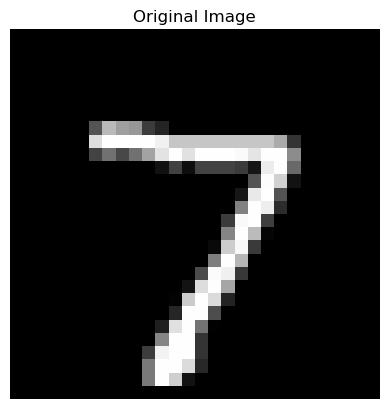

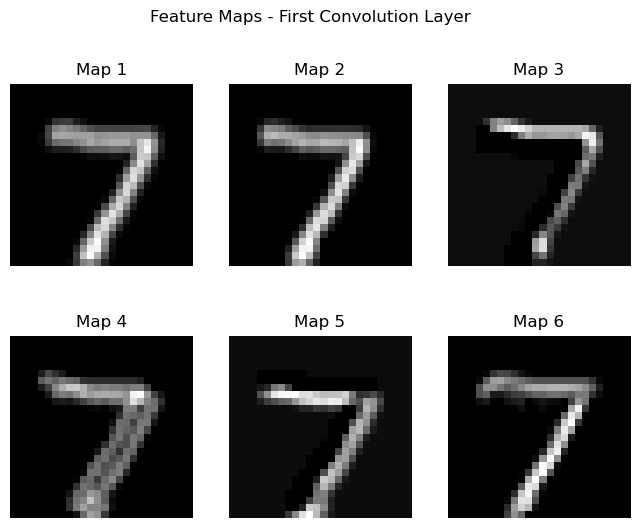

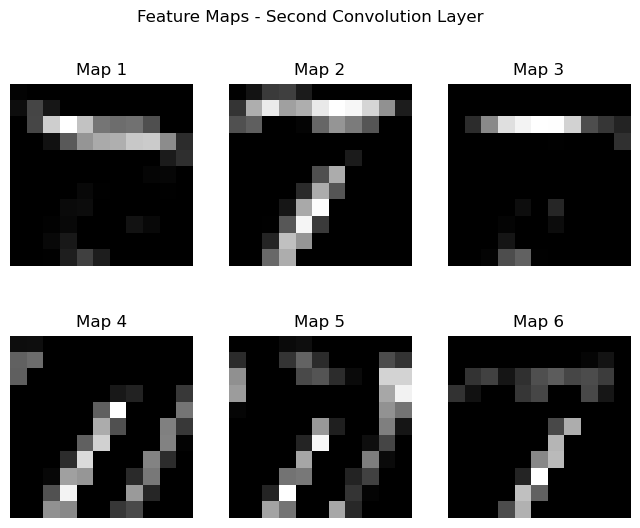

In [12]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


# 2. Load Dataset (MNIST)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalize
train_images = train_images / 255.0
test_images = test_images / 255.0

# Add channel dimension
train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]


# 3. Build CNN Model (SAFE VERSION)
model = models.Sequential([
    layers.Input(shape=(28,28,1)),   # ensures model is built properly
    
    layers.Conv2D(8, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])


# 4. Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 5. Train Model
model.fit(train_images, train_labels, epochs=3, validation_data=(test_images, test_labels))


# 6. FORCE MODEL TO BUILD (IMPORTANT FIX)
model.predict(test_images[:1])


# 7. Create Feature Extraction Model (FINAL FIX)
layer_outputs = [layer.output for layer in model.layers[:4]]
feature_model = tf.keras.Model(inputs=model.inputs, outputs=layer_outputs)


# 8. Select One Image
img = test_images[0]
img = np.expand_dims(img, axis=0)


# 9. Get Feature Maps
feature_maps = feature_model.predict(img)


# 10. Show Original Image
plt.imshow(test_images[0].squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


# 11. Visualise First Convolution Layer
first_layer = feature_maps[0]

plt.figure(figsize=(8,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(first_layer[0,:,:,i], cmap='gray')
    plt.title(f"Map {i+1}")
    plt.axis('off')

plt.suptitle("Feature Maps - First Convolution Layer")
plt.show()


# 12. Visualise Second Convolution Layer
second_layer = feature_maps[2]

plt.figure(figsize=(8,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(second_layer[0,:,:,i], cmap='gray')
    plt.title(f"Map {i+1}")
    plt.axis('off')

plt.suptitle("Feature Maps - Second Convolution Layer")
plt.show()